In [1]:
from textblob import TextBlob
import pandas as pd

# Realistic dataset
sentences = [
    "I feel anxious about my future but also hopeful",
    "Today was exhausting and I feel drained",
    "I had a really good conversation and feel happy",
    "I feel stuck and unsure what to do next",
    "I'm proud of myself for getting through today",
    "I feel overwhelmed with school and responsibilities",
    "I’m excited about new opportunities coming my way",
    "I feel lonely even when I'm around people"
]

# Improved emotion function
def interpret_emotion(polarity, text):
    text = text.lower()
    
    # keyword-based cognitive overrides
    if any(word in text for word in ["stuck", "overwhelmed", "anxious", "lonely", "drained"]):
        return "Stress / Distress"
    
    if any(word in text for word in ["excited", "proud", "happy", "hopeful"]):
        return "Positive / Growth"
    
    # fallback to sentiment
    if polarity > 0.5:
        return "Very Positive"
    elif polarity > 0:
        return "Mildly Positive"
    elif polarity < -0.5:
        return "Very Negative"
    elif polarity < 0:
        return "Mildly Negative"
    else:
        return "Neutral"

# Analyze data
results = []

for sentence in sentences:
    blob = TextBlob(sentence)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    emotion = interpret_emotion(polarity, sentence)
    
    results.append({
        "Sentence": sentence,
        "Polarity": polarity,
        "Subjectivity": subjectivity,
        "Emotion": emotion
    })

# Create table
df = pd.DataFrame(results)

df

,Sentence,Polarity,Subjectivity,Emotion
0,I feel anxious about my future but also hopeful,-0.125000,0.562500,Stress / Distress
1,Today was exhausting and I feel drained,-0.400000,0.500000,Stress / Distress
2,I had a really good conversation and feel happy,0.750000,0.800000,Positive / Growth
3,I feel stuck and unsure what to do next,0.000000,0.000000,Stress / Distress
4,I'm proud of myself for getting through today,0.800000,1.000000,Positive / Growth
5,I feel overwhelmed with school and responsibil...,0.000000,0.000000,Stress / Distress
6,I’m excited about new opportunities coming my way,0.255682,0.602273,Positive / Growth
7,I feel lonely even when I'm around people,-0.100000,0.700000,Stress / Distress


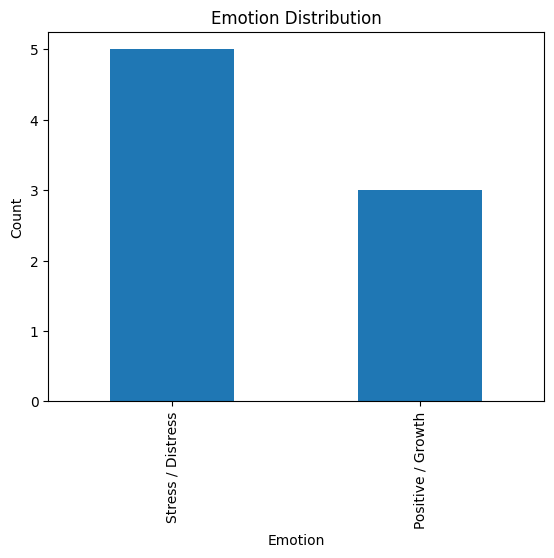

In [2]:
import matplotlib.pyplot as plt

df["Emotion"].value_counts().plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()